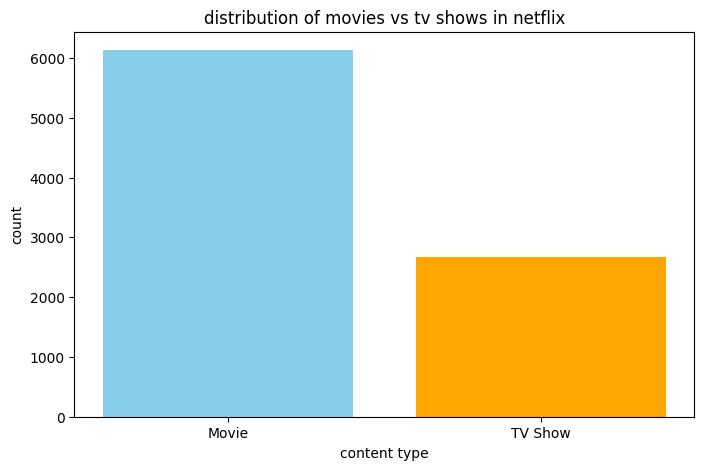

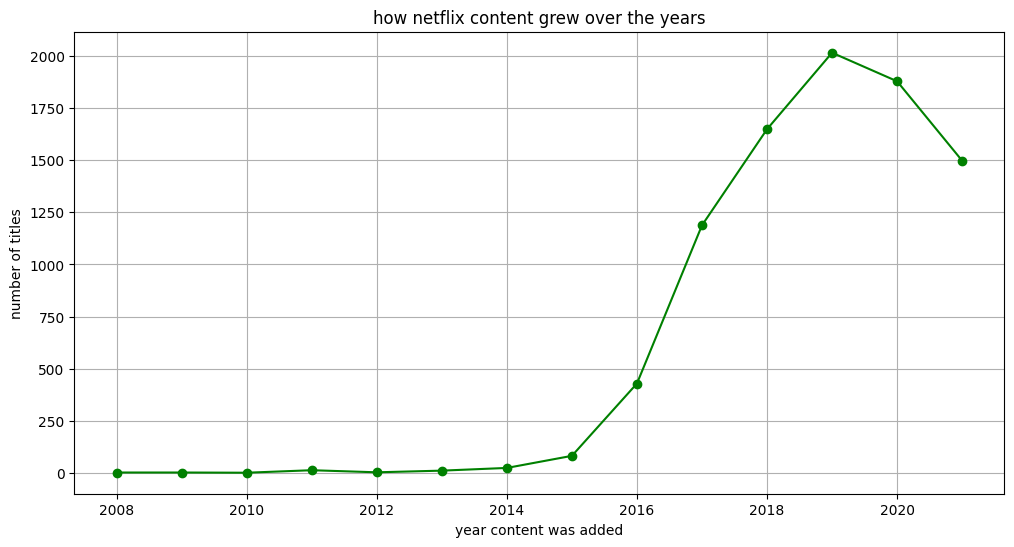

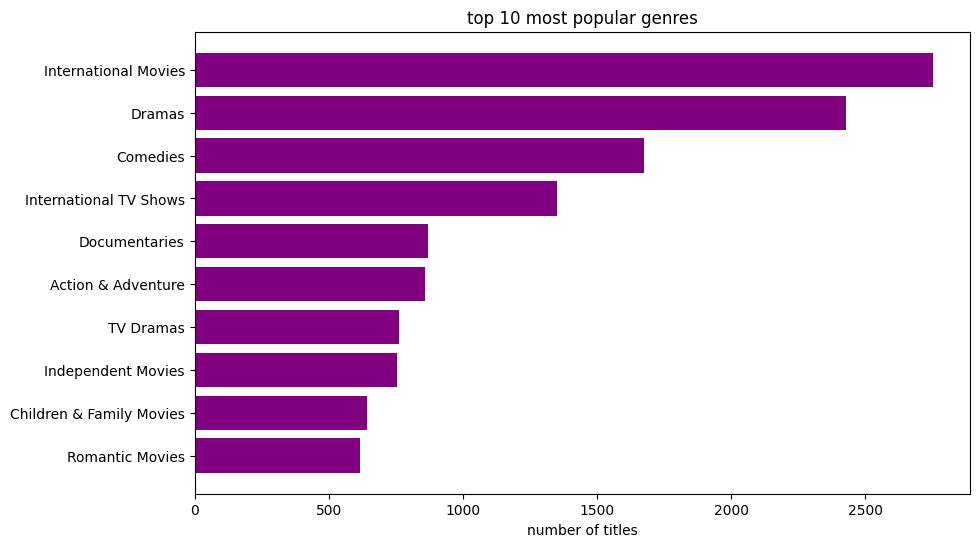

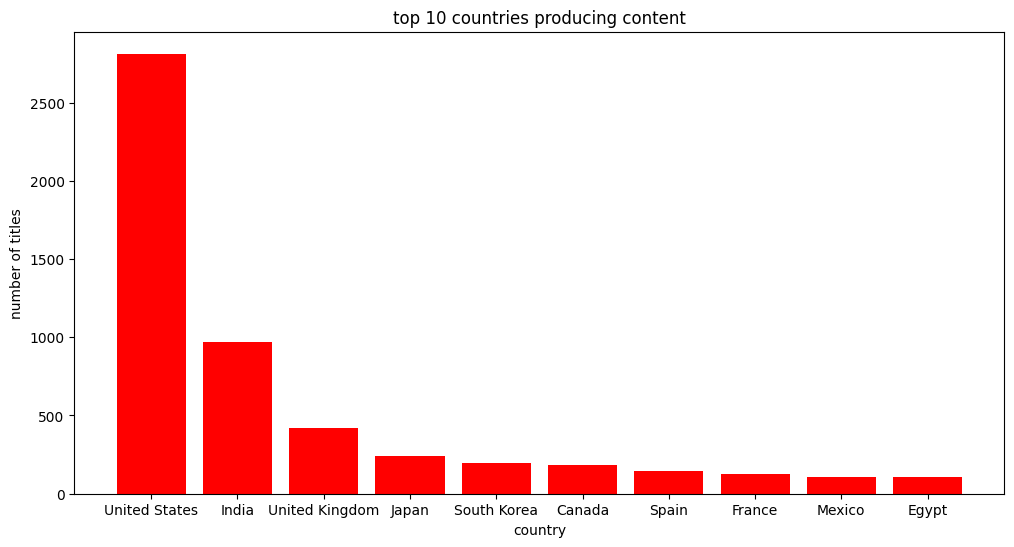

Analysis Complete!
total unique titles:8797
most popular type:Movie


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
#loading the data:
df=pd.read_csv('netflix_titles.csv')

#CLEANING THE DATA:
#1.)removing duplicates:
df=df.drop_duplicates()
#2.)cleaning 'date_added' and converting to year:
df['date_added']=pd.to_datetime(df['date_added'].str.strip(),errors='coerce')
df['year_added']=df['date_added'].dt.year
#3.)Handling missing values by dropping rows with empty dates
df=df.dropna(subset=['date_added'])

#QUESTION 1: CONTENT DISTRIBUTION ACCROSS NETFLIX:
type_counts=df['type'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(type_counts.index,type_counts.values,color=['skyblue','orange'])
plt.xlabel("content type")
plt.ylabel("count")
plt.title("distribution of movies vs tv shows in netflix")
plt.show()

#QUESTION 2:CONTENT GROWTH OVER TIME:
#grouping by year and count entries
growth=df.groupby('year_added').size()
plt.figure(figsize=(12,6))
plt.plot(growth.index,growth.values,color='green',marker='o',linestyle='-')
plt.xlabel("year content was added")
plt.ylabel("number of titles")
plt.title("how netflix content grew over the years")
plt.grid(True)
plt.show()

#QUESTION 3: TOP 10 GENRES
#splitting the genres and using 'explode' to count them individually
genres=df['listed_in'].str.split(',').explode().str.strip()
top_genres=genres.value_counts().head(10)
plt.figure(figsize=(10,6))
plt.barh(top_genres.index,top_genres.values,color='purple')
plt.xlabel("number of titles")
plt.title("top 10 most popular genres")
plt.gca().invert_yaxis() #by this the biggest genre would come at the top
plt.show()

#QUESTION 4: TOP 10 COUNTRY'S WHO PRODUCES THE MOST CONTENT
#(removing nulls)
top_countries=df['country'].dropna().value_counts().head(10)
plt.figure(figsize=(12,6))
plt.bar(top_countries.index,top_countries.values,color='red')
plt.xlabel("country")
plt.ylabel("number of titles")
plt.title("top 10 countries producing content")
plt.show()


#FINAL SUMMARY STATS:
print("Analysis Complete!")
print(f"total unique titles:{len(df)}")
print(f"most popular type:{type_counts.idxmax()}")